# USRP Playground - Testbench

Praktisches Arbeits-Notebook zum Testen des Systems (neue API, `usrp_playground`).

Enthaelt: Verbindungs-Check, Sende-Tests pro Kanal **mit SNR-Messung** (gut zum
Gain-Tuning), MIMO, Listen und eine Roundtrip-Zeitmessung.

Merkzettel:
- Guards vor/nach dem Signal sind **zufaellig** (Bereich siehe Setup-Zelle) - das Signal sitzt nie an derselben Stelle.
- 2.4-GHz-ISM-Band: WiFi/BLE-Spikes in den Aufnahmen sind normal.
- Gains stehen **pro Kanal im Hardware-Inventory** - Aenderungen dort wirken ab dem naechsten Task.

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
from usrp_playground import USRPClient

client = USRPClient.setup(
    host="129.132.24.210",
    port=80,
    token="gschwan-arxqpos5vxy642jlbstcmg2k",
)

info = client.info()
print(f"fs        = {client.fs/1e6:g} MHz")
print(f"fc        = {client.fc/1e9:g} GHz")
print(f"MIMO      = {client.mimo_enabled} (max {client.mimo_max_channels} Kanaele)")
print(f"Guards    = {info['begin_guard_min_sec']}-{info['begin_guard_max_sec']} s / "
      f"{info['end_guard_min_sec']}-{info['end_guard_max_sec']} s (zufaellig)")
for ch in client.channels:
    print(f"Kanal {ch['index']}: {ch['label']}  |  TX-Gain {ch.get('tx_gain_db')} dB, "
          f"RX-Gain {ch.get('rx_gain_db')} dB"
          + (f", TX-Power {ch['tx_power_dbm']} dBm" if ch.get('tx_power_dbm') is not None else ""))

fs        = 1 MHz
fc        = 2.44175 GHz
MIMO      = True (max 2 Kanaele)
Guards    = 0.05-0.1 s / 0.05-0.1 s (zufaellig)
Kanal 0: ch0  |  TX-Gain 70.0 dB, RX-Gain 60.0 dB
Kanal 1: ch1  |  TX-Gain 60.0 dB, RX-Gain 50.0 dB


## Helfer

`tone_snr()` misst schmalbandig, wie stark der eigene Ton ueber dem Rauschen ankommt -
WiFi-fest und damit das richtige Werkzeug fuer Gain-/Kabelvergleiche.

In [11]:
fs = client.fs
F_TONE = 100e3                 # Testton bei +100 kHz

def make_tone(n, f=F_TONE, amp=0.8):
    t = np.arange(n) / fs
    return (amp * np.exp(2j * np.pi * f * t)).astype(np.complex64)


def tone_snr(rx, f_nominal=F_TONE, search_khz=10):
    """Ton im Spektrum suchen (CFO-tolerant) und SNR in dB zurueckgeben."""
    rx = np.asarray(rx).ravel()
    w = np.hanning(len(rx))
    spec = np.abs(np.fft.fftshift(np.fft.fft(rx * w)))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(rx), d=1/fs))
    m = np.abs(freqs - f_nominal) < search_khz * 1e3
    peak = spec[m].max()
    f_found = freqs[m][np.argmax(spec[m])]
    noise = np.median(spec)
    return 20 * np.log10(peak / noise), f_found


def plot_rx(rx, title=""):
    rx = np.asarray(rx)
    chans = [rx] if rx.ndim == 1 else [rx[:, i] for i in range(rx.shape[1])]
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
    for i, x in enumerate(chans):
        lbl = f"ch{i}" if len(chans) > 1 else None
        k = max(int(fs / 1000), 1)
        env = np.convolve(np.abs(x)**2, np.ones(k)/k, mode="same")
        ax[0].plot(np.arange(len(x))/fs*1e3, 10*np.log10(env + 1e-15), lw=0.8, label=lbl)
        w = np.hanning(len(x))
        spec = np.abs(np.fft.fftshift(np.fft.fft(x * w)))
        freqs = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs))
        s = 20*np.log10(spec + 1e-15)
        ax[1].plot(freqs/1e3, s - s.max(), lw=0.8, label=lbl)
    ax[0].set_title(f"{title} - Envelope"); ax[0].set_xlabel("Zeit [ms]"); ax[0].set_ylabel("dB")
    ax[1].set_title("Spektrum"); ax[1].set_xlabel("Offset [kHz]"); ax[1].set_ylim(-90, 5)
    if len(chans) > 1:
        ax[0].legend(); ax[1].legend()
    fig.tight_layout(); plt.show()

print("Helfer geladen.")

Helfer geladen.


## 1. Schnelltest: einmal senden + anschauen

In [12]:
tx = make_tone(100_000)
rx = client.send(tx, verbose=True)
snr, f0 = tone_snr(rx)
print(f"\nTon empfangen bei {f0/1e3:.2f} kHz, SNR {snr:.1f} dB (spektral)")
plot_rx(rx, "send() Kanal 0")

[upload] Sent 800,000 bytes
[info] USRP | Carrier: 2442 MHz | BW: 0 MHz | Rate: 1 MSps
[queued] Task f6a19436... - next in line
[done] Processing complete                
[error] processing_failed: Traceback (most recent call last):
  File "/app/worker.py", line 107, in poll_and_process
    process_f32(task_uid)
  File "/app/worker.py", line 78, in process_f32
    received = send_and_receive(signal, channel=channel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 851, in send_and_receive
    return _channel.send_and_receive(signal, channel=channel)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 681, in send_and_receive
    raise RuntimeError(
RuntimeError: RECEIVE_TO_FILE failed: RX stream timeout after receiving 0/239144 samples



RuntimeError: Server error: Traceback (most recent call last):
  File "/app/worker.py", line 107, in poll_and_process
    process_f32(task_uid)
  File "/app/worker.py", line 78, in process_f32
    received = send_and_receive(signal, channel=channel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 851, in send_and_receive
    return _channel.send_and_receive(signal, channel=channel)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 681, in send_and_receive
    raise RuntimeError(
RuntimeError: RECEIVE_TO_FILE failed: RX stream timeout after receiving 0/239144 samples


## 2. Kanalvergleich mit SNR - das Werkzeug fuers Gain-Tuning

Gleicher Ton ueber jeden Kanal; die SNR-Zahlen zeigen direkt, was eine
Gain-Aenderung im Inventory bringt (einfach danach nochmal laufen lassen).

In [5]:
tx = make_tone(100_000)
results = {}
for ch in [c["index"] for c in client.channels]:
    rx = client.send_siso(tx, channel=ch)
    snr, f0 = tone_snr(rx)
    results[ch] = snr
    print(f"Kanal {ch}:  SNR {snr:5.1f} dB   (Ton bei {f0/1e3:.2f} kHz, "
          f"{len(rx)} Samples empfangen)")

if len(results) > 1:
    vals = list(results.values())
    print(f"\nDifferenz Kanal 0 vs 1: {abs(vals[0]-vals[1]):.1f} dB")

Kanal 0:  SNR  30.7 dB   (Ton bei 102.13 kHz, 212243 Samples empfangen)
Kanal 1:  SNR  41.2 dB   (Ton bei 102.13 kHz, 251063 Samples empfangen)

Differenz Kanal 0 vs 1: 10.4 dB


## 3. MIMO: beide Kanaele gleichzeitig, unterschiedliche Toene

RX shape: (252884, 2)
Kanal 0: eigener Ton (+100 kHz) -> 29.8 dB bei 102.13 kHz
Kanal 1: eigener Ton (-150 kHz) -> 44.4 dB bei -147.87 kHz


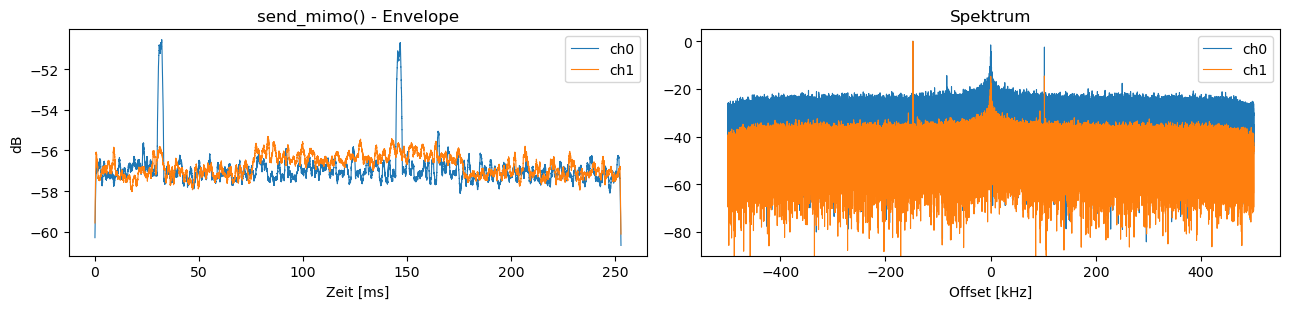

In [6]:
tx_mimo = np.stack([make_tone(100_000, +100e3),
                    make_tone(100_000, -150e3)], axis=1)
rx_mimo = client.send_mimo(tx_mimo)
print("RX shape:", rx_mimo.shape)
for i, f_want in enumerate([+100e3, -150e3]):
    snr, f0 = tone_snr(rx_mimo[:, i], f_nominal=f_want)
    print(f"Kanal {i}: eigener Ton ({f_want/1e3:+.0f} kHz) -> {snr:.1f} dB bei {f0/1e3:.2f} kHz")
plot_rx(rx_mimo, "send_mimo()")

## 4. Listen: Band anschauen ohne zu senden (WiFi-Gucker)

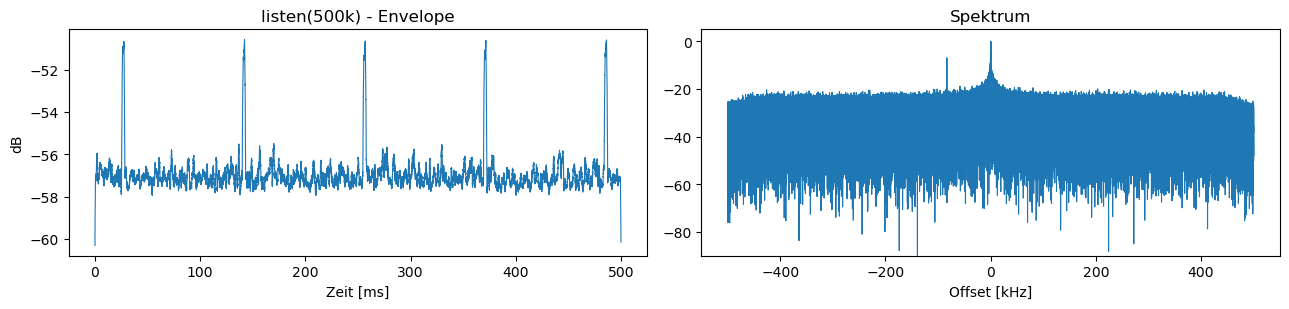

RuntimeError: Server error: Traceback (most recent call last):
  File "/app/worker.py", line 107, in poll_and_process
    process_f32(task_uid)
  File "/app/worker.py", line 59, in process_f32
    received = receive_only(n_samples, n_channels=n_channels)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 858, in receive_only
    return _channel.receive_only(n_samples, channel=channel, n_channels=n_channels)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 802, in receive_only
    raise RuntimeError(
RuntimeError: RECEIVE_TO_FILE failed: RX ERROR: ERROR_CODE_OVERFLOW (Out of sequence error)


In [7]:
rx = client.listen(500_000)      # 0.5 s Band-Mitschnitt auf Kanal 0
plot_rx(rx, "listen(500k)")

rx2 = client.listen_mimo(200_000)
print("MIMO-Listen shape:", rx2.shape)

## 5. Roundtrip-Zeit messen

In [9]:
tx = make_tone(100_000)
for i in range(3):
    t0 = time.monotonic()
    client.send(tx)
    print(f"Run {i+1}: {time.monotonic()-t0:.2f} s")

RuntimeError: Server error: Traceback (most recent call last):
  File "/app/worker.py", line 107, in poll_and_process
    process_f32(task_uid)
  File "/app/worker.py", line 78, in process_f32
    received = send_and_receive(signal, channel=channel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 851, in send_and_receive
    return _channel.send_and_receive(signal, channel=channel)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 681, in send_and_receive
    raise RuntimeError(
RuntimeError: RECEIVE_TO_FILE failed: RX stream timeout after receiving 0/237314 samples


## 6. Eigenes Spielfeld

Freie Zelle - z.B. eigenes Signal bauen, `client.send(...)`, auswerten.

Spickzettel:
```python
rx = client.send(tx)                       # SISO Kanal 0
rx = client.send(tx, channel=1)            # SISO Kanal 1
rx = client.send_mimo(tx_2d)               # (n, 2) -> (n_rx, 2)
rx = client.listen(n)                      # nur empfangen
rx = client.listen_siso(n, channel=1)
rx = client.listen_mimo(n)
client.refresh_info()                      # Settings-Aenderungen nachladen
```